# Taxi Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 Taxi 这种带有阶段约束的离散任务里，如果完全随机地选择动作，智能体通常会出现怎样的表现。这个 baseline 会作为后续 `Tabular Q-Learning` notebook 的参照，用来说明为什么仅靠随机试错很难稳定完成接客、运输和正确下客这一整套流程。


## 环境背景

Taxi 是一个经典的离散控制环境。智能体扮演出租车司机，需要在网格地图中完成四步闭环：

- 移动到乘客所在位置
- 正确执行接客
- 将乘客运送到目标位置
- 在目标位置正确执行下客

这个环境的难点不在于单步移动，而在于任务是分阶段的，并且包含显式约束：如果在错误位置执行接客或下客，会立刻受到额外惩罚。因此，它很适合解释为什么强化学习不仅要学会“往哪走”，还要学会“什么时候做哪类动作”。


## 方法说明

这里的方法就是纯随机动作采样：每一步直接调用 `env.action_space.sample()` 选择动作，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么不能依赖随机动作完成稳定任务。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。


In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Taxi-v3"
NUM_EPISODES = 3000
MAX_STEPS = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)


## 参数选择说明

- `NUM_EPISODES = 3000`：让随机策略的统计结果更稳定，同时保持执行速度足够快
- `MAX_STEPS = 200`：给完整任务链足够步数，避免因为过早截断而误判随机策略表现

这里的重点不是训练效率，而是建立一个清晰的基线：在不学习任何结构的前提下，随机策略不仅回报很差，而且会频繁执行无效操作。


In [3]:
episode_rewards = []
episode_lengths = []
successes = []
illegal_action_counts = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    illegal_actions = 0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if reward == -10:
            illegal_actions += 1

        state = next_state

        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(terminated and reward == 20))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(0)

    episode_rewards.append(total_reward)
    illegal_action_counts.append(illegal_actions)

env.close()


Random episodes:   0%|          | 0/3000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
        "illegal_actions": illegal_action_counts,
    }
)
summary.describe(include="all")


,reward,episode_length,success,illegal_actions
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,-770.967667,196.531667,0.047333,63.936667
std,101.928163,18.317428,0.212386,9.506776
min,-1019.000000,21.000000,0.000000,4.000000
25%,-830.000000,200.000000,0.000000,60.000000
50%,-785.000000,200.000000,0.000000,65.000000
75%,-740.000000,200.000000,0.000000,70.000000
max,-44.000000,200.000000,1.000000,91.000000


In [5]:
success_rate = float(np.mean(successes))
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
avg_illegal_actions = float(np.mean(illegal_action_counts))

metrics = pd.DataFrame(
    {
        "metric": ["success_rate", "average_reward", "average_episode_length", "average_illegal_actions"],
        "value": [success_rate, avg_reward, avg_length, avg_illegal_actions],
    }
)
metrics


,metric,value
0,success_rate,0.047333
1,average_reward,-770.967667
2,average_episode_length,196.531667
3,average_illegal_actions,63.936667


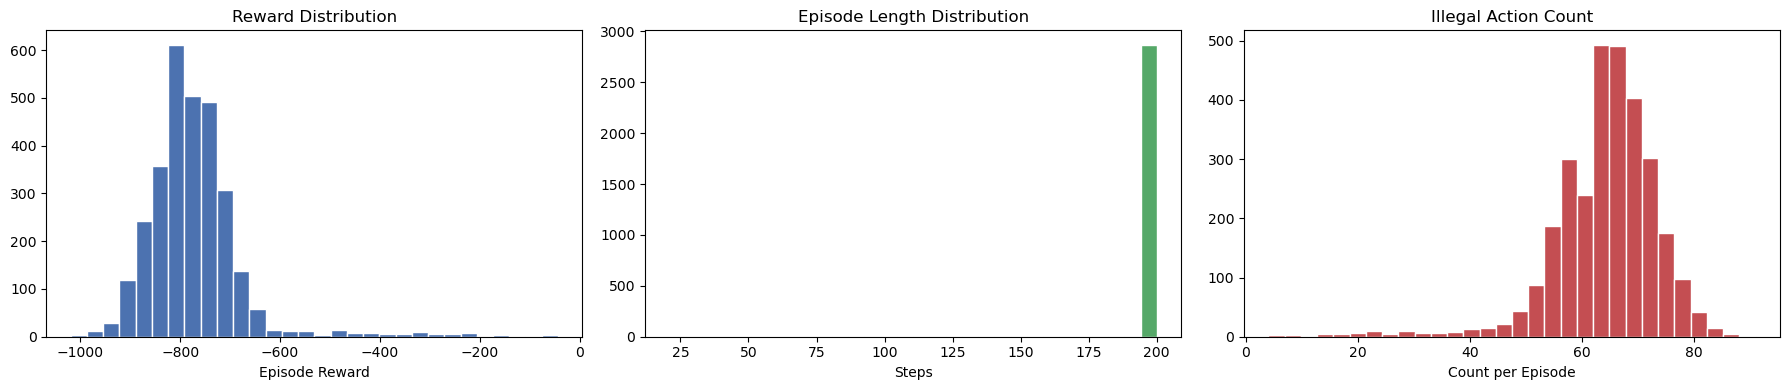

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].hist(illegal_action_counts, bins=30, color="#c44e52", edgecolor="white")
axes[2].set_title("Illegal Action Count")
axes[2].set_xlabel("Count per Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)

print(f"Success rate: {success_rate:.4f}")
print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Average illegal actions: {avg_illegal_actions:.2f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Success rate: 0.0473
Average reward: -770.97
Average episode length: 196.53
Average illegal actions: 63.94
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/05-taxi-tabular-q-learning/results


## 结果解读

随机策略在 Taxi 里通常很难形成完整任务链。它不仅难以稳定完成任务，还会频繁在错误位置执行接客或下客，导致额外惩罚不断累积。这说明这个环境真正要求智能体学到的是分阶段决策结构，而不是简单地随机移动。
